[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kevin-blasiak-curtin/ISYS2001-Archive/blob/main/Module%2008%20-%20API/lab_ticket_stock_chart.ipynb)

# Lab Ticket: Charting Real Stock Data

This week you used the Gemini API: you sent it text, and it sent text back. A stock service works the same way. You send a request (which company, what kind of data) and it sends back a structured response you can turn into a chart.

Your job is to fetch real stock data and draw one clear figure from it. The fetching is written for you. The figure is yours.

## The brief

**API to integrate:** Alpha Vantage (free).

Get your own key the same way you got your Gemini key:

1. Sign up at https://www.alphavantage.co/support/#api-key
2. Store it in Colab Secrets as `ALPHAVANTAGE_API_KEY`, with Notebook access switched on.

Use your own key, not the shared `demo` key. The demo key only ever returns data for IBM.

**Figure I expect:** a line chart of the daily closing price for one ticker of your choice, across the window the data covers. Label both axes, and give the chart a title that names the ticker.

**A note on limits:** the free key allows only about 25 requests a day. Run the fetch cell once. After that the data lives in a DataFrame called `prices`, so do all your charting from that. Re-running the fetch cell over and over will use up your daily quota, and you will start getting a notice instead of data.

In [1]:
from google.colab import userdata
import requests
import pandas as pd
import matplotlib.pyplot as plt

API_KEY = userdata.get("ALPHAVANTAGE_API_KEY")


def get_stock_data(ticker):
    """Fetch daily prices for a ticker and return a tidy DataFrame.

    The result has a date index and Open, High, Low, Close and Volume columns,
    sorted from oldest to newest.
    """
    url = "https://www.alphavantage.co/query"
    params = {
        "function": "TIME_SERIES_DAILY",
        "symbol": ticker,
        "apikey": API_KEY,
        "outputsize": "compact",   # the most recent 100 trading days
    }

    response = requests.get(url, params=params)
    data = response.json()

    # If the expected data is missing, Alpha Vantage explains why here: an
    # invalid ticker, a missing key, or a note that you have hit the daily limit.
    if "Time Series (Daily)" not in data:
        reason = (data.get("Error Message")
                  or data.get("Note")
                  or data.get("Information")
                  or data)
        raise ValueError(f"No price data returned. Alpha Vantage said: {reason}")

    prices = pd.DataFrame.from_dict(data["Time Series (Daily)"], orient="index")
    prices = prices.rename(columns={
        "1. open": "Open",
        "2. high": "High",
        "3. low": "Low",
        "4. close": "Close",
        "5. volume": "Volume",
    })
    prices = prices.astype(float)
    prices.index = pd.to_datetime(prices.index)
    prices = prices.sort_index()
    return prices

In [2]:
# Run this once. Change the ticker to one of your choice.
TICKER = "AAPL"
prices = get_stock_data(TICKER)
prices.tail()

,Open,High,Low,Close,Volume
2026-09-22,340.135,345.340,338.75,339.75,40711786.0
2026-09-23,341.075,341.800,335.50,337.02,31658823.0
2026-09-24,336.720,338.910,334.30,335.92,24733098.0
2026-09-25,336.040,341.670,334.53,341.07,30002507.0
2026-09-28,340.370,342.988,338.04,338.40,32442525.0


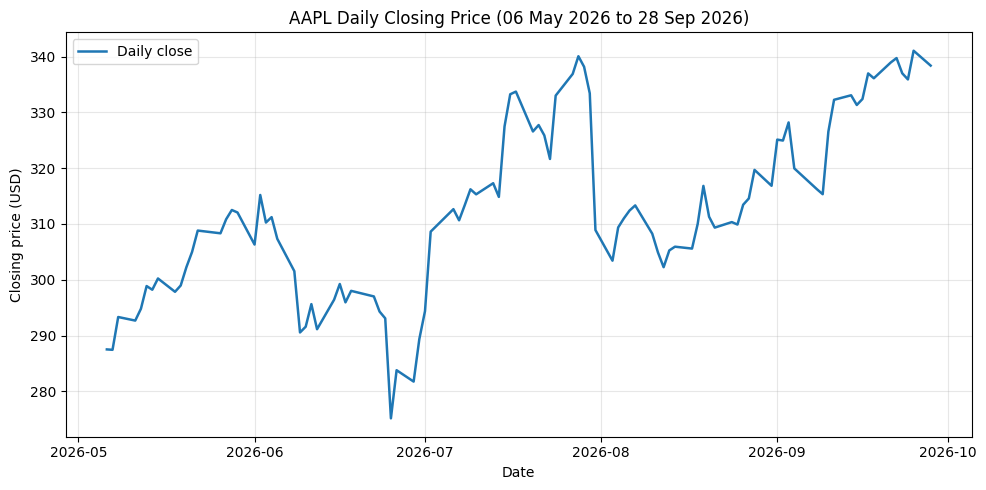

In [3]:
# Your chart from here.
# Draw the daily closing price as a labelled line chart, using the `prices` DataFrame.

plt.figure(figsize=(10, 5))

# Dates (the index) on the x-axis, closing price on the y-axis
plt.plot(prices.index, prices["Close"], color="tab:blue", linewidth=1.8, label="Daily close")

start = prices.index.min().strftime("%d %b %Y")
end = prices.index.max().strftime("%d %b %Y")
plt.title(f"{TICKER} Daily Closing Price ({start} to {end})")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Stretch: 20-day moving average

Worked out from the `prices` DataFrame already in memory, so no extra API request is needed.

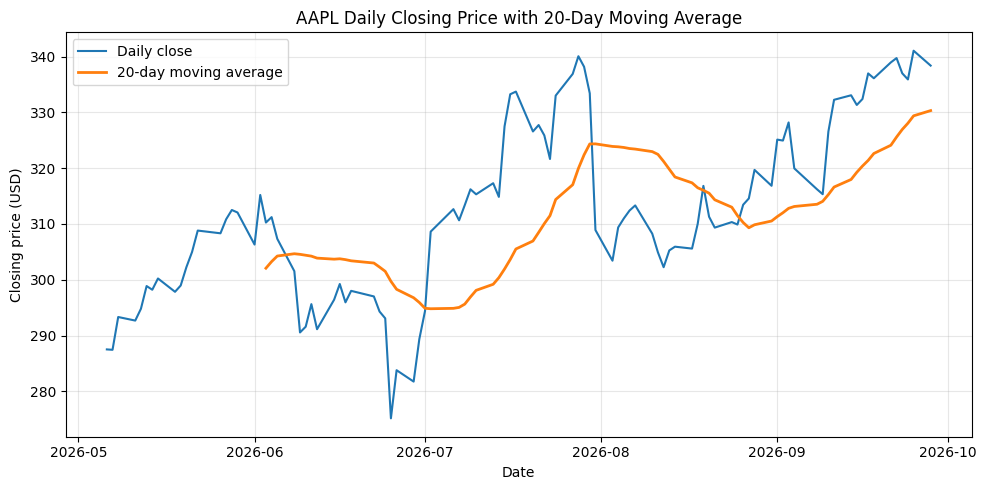

In [4]:
# Average of each day's close with the 19 trading days before it
prices["MA20"] = prices["Close"].rolling(window=20).mean()

plt.figure(figsize=(10, 5))
plt.plot(prices.index, prices["Close"], color="tab:blue", linewidth=1.5, label="Daily close")
plt.plot(prices.index, prices["MA20"], color="tab:orange", linewidth=2, label="20-day moving average")

plt.title(f"{TICKER} Daily Closing Price with 20-Day Moving Average")
plt.xlabel("Date")
plt.ylabel("Closing price (USD)")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Before you finish

Be ready to explain, in your own words:

- what the fetch returns, and what a single row represents
- why a line chart suits this kind of data
- what your finished chart actually shows

**Stretch (optional):** add a second ticker to the same chart, or work out a simple moving average and plot it alongside the price. A moving average needs no extra request, since it is worked out from the data you already have.